In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sales = pd.read_csv("stadiagear_clean.csv")

In [3]:
sales.columns

Index(['TransactionID', 'CustomerID', 'ProductID', 'Region', 'Quantity',
       'Revenue'],
      dtype='object')

In [4]:
sales['Date'] = pd.date_range(
    start='2024-01-01',
    periods=len(sales),
    freq='D'
)

In [5]:
daily_sales = sales.groupby('Date')['Quantity'].sum().reset_index()

In [6]:
sales.columns.tolist()

['TransactionID',
 'CustomerID',
 'ProductID',
 'Region',
 'Quantity',
 'Revenue',
 'Date']

In [7]:
sales.columns = sales.columns.str.strip()

In [8]:
daily_sales = sales.groupby('Date')['Quantity'].sum().reset_index()

In [9]:
sales.columns

Index(['TransactionID', 'CustomerID', 'ProductID', 'Region', 'Quantity',
       'Revenue', 'Date'],
      dtype='object')

In [10]:
sales.head()

,TransactionID,CustomerID,ProductID,Region,Quantity,Revenue,Date
0,1,3262,P02804,East,5,320.25,2024-01-01
1,2,9453,P04325,West,3,39.06,2024-01-02
2,3,4540,P03381,North,2,262.08,2024-01-03
3,4,8774,P00636,East,2,299.84,2024-01-04
4,5,9492,P00744,East,1,114.06,2024-01-05


In [11]:
sales['Date'] = pd.to_datetime(sales['Date'])

In [12]:
daily_sales = sales.groupby('Date')['Quantity'].sum().reset_index()

In [13]:
daily_sales['Rolling_7_Day_Avg'] = (
    daily_sales['Quantity']
    .rolling(window=7)
    .mean()
)

In [14]:
daily_sales.head(10)

,Date,Quantity,Rolling_7_Day_Avg
0,2024-01-01,5,NaN
1,2024-01-02,3,NaN
2,2024-01-03,2,NaN
3,2024-01-04,2,NaN
4,2024-01-05,1,NaN
5,2024-01-06,2,NaN
6,2024-01-07,1,2.285714
7,2024-01-08,1,1.714286
8,2024-01-09,2,1.571429
9,2024-01-10,5,2.000000


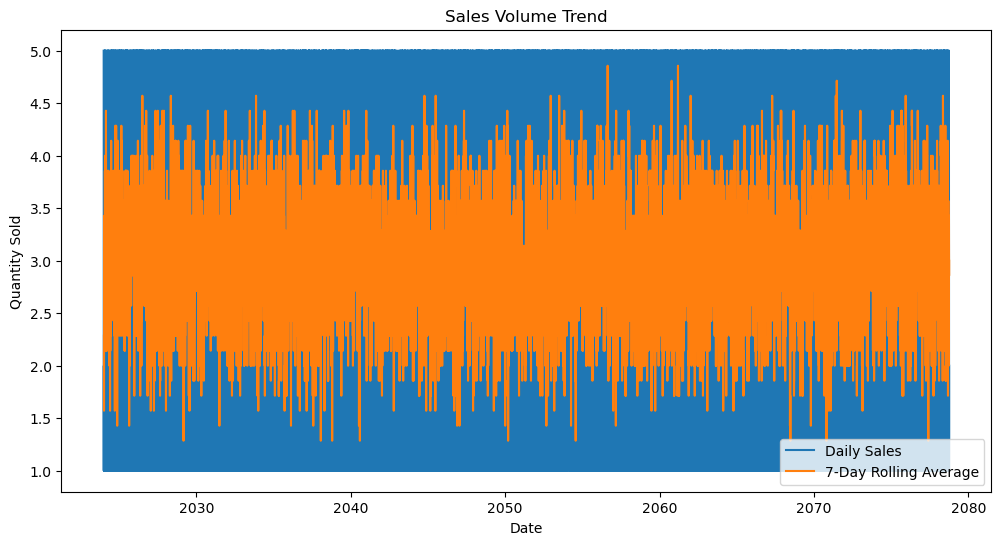

In [15]:
plt.figure(figsize=(12,6))

plt.plot(
    daily_sales['Date'],
    daily_sales['Quantity'],
    label='Daily Sales'
)

plt.plot(
    daily_sales['Date'],
    daily_sales['Rolling_7_Day_Avg'],
    label='7-Day Rolling Average'
)

plt.title('Sales Volume Trend')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')
plt.legend()

plt.show()